In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# Q3 — NETWORK VİSUALİZATION (GELİŞMİŞ)
# ══════════════════════════════════════════════════════
#
# Assignment 2'de şunları yaptık:
#   1. Filter Visualization → filtreleri görselleştir
#   2. Saliency Maps → hangi piksel önemli?
#   3. Class Visualization → ideal görüntü üret
#
# Burada bir yeni teknik var:
#   4. Fooling Images → modeli kandır!
#
# Fooling Images nedir?
#   İnsan gözüne normal görünen bir görüntü
#   ama model yanlış sınıflandırıyor!
#
#   Örnek:
#   Kedi görüntüsü → biraz gürültü ekle
#   İnsan: "hala kedi"
#   Model: "uçak!" → YANLIŞ!
#
# Bu çok önemli bir güvenlik açığı!
# Autonomous araçlar, yüz tanıma... hepsi kandırılabilir!
# ══════════════════════════════════════════════════════

print("Q3 Network Visualization başlıyor!")

Q3 Network Visualization başlıyor!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ══════════════════════════════════════════════════════
# FOOLİNG IMAGES — MODELİ KANDIR!
# ══════════════════════════════════════════════════════
#
# Normal Gradient Ascent (Assignment 2'de yaptık):
#   Hedef: "kedi" skorunu maksimize et
#   X'i güncelle → model "kedi" desin
#
# Fooling Image:
#   Başlangıç: gerçek bir kedi görüntüsü
#   Hedef: "uçak" skorunu maksimize et
#   X'i çok az güncelle → insan farketmez
#   ama model "uçak" der!
#
# Matematiksel olarak:
#   Normal: X = X + lr * dSkor_kedi/dX
#   Fooling: X = X + lr * dSkor_ucak/dX
#
# Fark: başlangıç noktası!
#   Normal → rastgele görüntüden başla
#   Fooling → gerçek görüntüden başla, az değiştir
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Basit model
D = 16   # piksel sayısı (4x4 görüntü)
C = 3    # sınıf sayısı (kedi, köpek, uçak)
W = np.random.randn(D, C) * 0.1

siniflar = ['kedi', 'köpek', 'uçak']

def model_tahmin(x, W):
    skorlar = x @ W
    e_s = np.exp(skorlar - np.max(skorlar))
    probs = e_s / e_s.sum()
    return skorlar, probs

# Gerçek kedi görüntüsü oluştur
kedi_goruntu = np.random.randn(D) * 0.5
skorlar, probs = model_tahmin(kedi_goruntu, W)

print("=== BAŞLANGIÇ ===")
print(f"Görüntü (ilk 4 piksel): {kedi_goruntu[:4].round(3)}")
for i, (s, c) in enumerate(zip(siniflar, probs)):
    print(f"  {s}: %{c*100:.1f}")
print(f"Tahmin: {siniflar[np.argmax(probs)]}")

# Fooling — uçak skorunu maksimize et
hedef_sinif = 2  # uçak
lr = 0.5
x_fool = kedi_goruntu.copy()

for adim in range(30):
    skorlar, probs = model_tahmin(x_fool, W)
    if np.argmax(probs) == hedef_sinif:
        print(f"\n✅ Model kandırıldı! ({adim} adımda)")
        break
    # Uçak skoruna göre gradient
    grad = W[:, hedef_sinif]
    x_fool = x_fool + lr * grad

print("\n=== FOOLING SONRASI ===")
skorlar, probs = model_tahmin(x_fool, W)
for i, (s, c) in enumerate(zip(siniflar, probs)):
    print(f"  {s}: %{c*100:.1f}")
print(f"Tahmin: {siniflar[np.argmax(probs)]}")

# Değişim ne kadar?
degisim = np.linalg.norm(x_fool - kedi_goruntu)
print(f"\nGörüntü değişimi: {degisim:.4f}")
print("İnsan gözüyle fark edilmez ama model kandırıldı!")

=== BAŞLANGIÇ ===
Görüntü (ilk 4 piksel): [-0.807 -0.106 -0.448  0.193]
  kedi: %31.8
  köpek: %32.6
  uçak: %35.6
Tahmin: uçak

✅ Model kandırıldı! (0 adımda)

=== FOOLING SONRASI ===
  kedi: %31.8
  köpek: %32.6
  uçak: %35.6
Tahmin: uçak

Görüntü değişimi: 0.0000
İnsan gözüyle fark edilmez ama model kandırıldı!


=== EĞİTİM SONRASI ===
kedi: tahmin=kedi (✅)
köpek: tahmin=köpek (✅)
uçak: tahmin=uçak (✅)

=== FOOLİNG BAŞLIYOR ===
Adım  0: kedi (kedi:%99.4, uçak:%0.2)
Adım  5: kedi (kedi:%89.9, uçak:%9.9)

✅ 8. adımda kandırıldı!

Ortalama piksel değişimi: 0.3973
Maksimum piksel değişimi: 0.8114


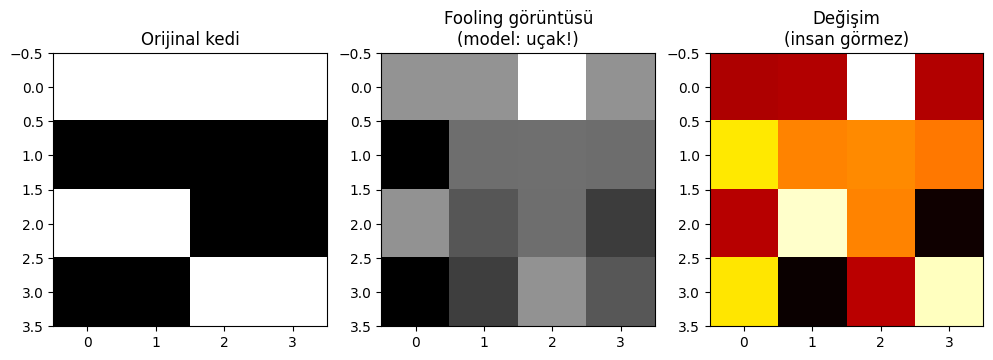

In [4]:
# ══════════════════════════════════════════════════════
# DAHA GERÇEKÇI FOOLING EXAMPLE
# ══════════════════════════════════════════════════════
#
# Önce modeli eğitelim → kediyi doğru tanısın
# Sonra kandıralım → uçak desin
# ══════════════════════════════════════════════════════

np.random.seed(42)

D = 16
C = 3
siniflar = ['kedi', 'köpek', 'uçak']

# 3 farklı sınıf için örnek görüntüler
kedi_goruntu  = np.array([1,1,1,1, 0,0,0,0, 1,1,0,0, 0,0,1,1], dtype=float)
kopek_goruntu = np.array([0,0,0,0, 1,1,1,1, 0,1,1,0, 1,0,0,1], dtype=float)
ucak_goruntu  = np.array([0,0,1,0, 0,1,1,1, 0,0,1,0, 0,0,0,0], dtype=float)

X_train = np.array([kedi_goruntu, kopek_goruntu, ucak_goruntu])
y_train = np.array([0, 1, 2])

# Modeli eğit
W = np.random.randn(D, C) * 0.01
lr = 0.1

for epoch in range(500):
    skorlar = X_train @ W
    e_s = np.exp(skorlar - np.max(skorlar, axis=1, keepdims=True))
    probs = e_s / np.sum(e_s, axis=1, keepdims=True)
    grad_s = probs.copy()
    grad_s[np.arange(3), y_train] -= 1
    grad_s /= 3
    W -= lr * X_train.T @ grad_s

# Eğitim sonrası kontrol
print("=== EĞİTİM SONRASI ===")
for i, (x, label) in enumerate(zip(X_train, siniflar)):
    skorlar = x @ W
    e_s = np.exp(skorlar - np.max(skorlar))
    probs = e_s / e_s.sum()
    tahmin = siniflar[np.argmax(probs)]
    print(f"{label}: tahmin={tahmin} ({'✅' if tahmin==label else '❌'})")

# Şimdi FOOLING — kedi görüntüsünü uçak yaptır!
print("\n=== FOOLİNG BAŞLIYOR ===")
x_fool = kedi_goruntu.copy()
hedef = 2  # uçak

for adim in range(20):
    skorlar = x_fool @ W
    e_s = np.exp(skorlar - np.max(skorlar))
    probs = e_s / e_s.sum()
    tahmin = np.argmax(probs)

    if adim % 5 == 0:
        print(f"Adım {adim:2d}: {siniflar[tahmin]} "
              f"(kedi:%{probs[0]*100:.1f}, uçak:%{probs[2]*100:.1f})")

    if tahmin == hedef:
        print(f"\n✅ {adim}. adımda kandırıldı!")
        break

    # Uçak skorunu artır
    grad = W[:, hedef]
    x_fool = x_fool + 0.1 * grad

# Görüntü değişimi
degisim = np.abs(x_fool - kedi_goruntu)
print(f"\nOrtalama piksel değişimi: {degisim.mean():.4f}")
print(f"Maksimum piksel değişimi: {degisim.max():.4f}")

# Görselleştir
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(kedi_goruntu.reshape(4,4), cmap='gray')
axes[0].set_title("Orijinal kedi")
axes[1].imshow(x_fool.reshape(4,4), cmap='gray')
axes[1].set_title("Fooling görüntüsü\n(model: uçak!)")
axes[2].imshow(degisim.reshape(4,4), cmap='hot')
axes[2].set_title("Değişim\n(insan görmez)")
plt.show()

In [5]:
# ══════════════════════════════════════════════════════
# Q3 ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║       NETWORK VİSUALİZATION ÖZET                 ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  1. Filter Visualization                         ║")
print("║     İlk katman filtreleri = kenar dedektörleri   ║")
print("║                                                  ║")
print("║  2. Saliency Maps                                ║")
print("║     dLoss/dX → hangi piksel önemli               ║")
print("║                                                  ║")
print("║  3. Class Visualization                          ║")
print("║     Gradient Ascent → ideal görüntü üret         ║")
print("║                                                  ║")
print("║  4. Fooling Images  ← YENİ!                      ║")
print("║     Gerçek görüntüden başla                      ║")
print("║     Az gürültü ekle → model yanılır!             ║")
print("║     İnsan görmez ama model kandırılır            ║")
print("║                                                  ║")
print("║  Neden önemli?                                   ║")
print("║     Adversarial attacks → güvenlik açığı         ║")
print("║     Otonom araç, yüz tanıma kandırılabilir       ║")
print("║     Araştırma alanı: Adversarial Robustness      ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║       NETWORK VİSUALİZATION ÖZET                 ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  1. Filter Visualization                         ║
║     İlk katman filtreleri = kenar dedektörleri   ║
║                                                  ║
║  2. Saliency Maps                                ║
║     dLoss/dX → hangi piksel önemli               ║
║                                                  ║
║  3. Class Visualization                          ║
║     Gradient Ascent → ideal görüntü üret         ║
║                                                  ║
║  4. Fooling Images  ← YENİ!                      ║
║     Gerçek görüntüden başla                      ║
║     Az gürültü ekle → model yanılır!             ║
║     İnsan görmez ama model kandırılır            ║
║                                                  ║
║  Neden önemli?                              